# Single MRI Prediction System

This notebook predicts the tumor type from a single MRI image.

Output:

- Predicted Class
- Confidence Score
- Probability for each class
- Visualization

In [1]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
model = tf.keras.models.load_model(
    "../models/efficientnet_brain_tumor.keras"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [3]:
class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

In [5]:
image_path = "../datasets/classification/Testing/glioma/Te-gl_2.jpg"

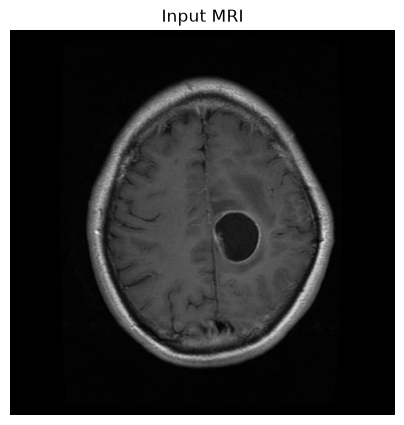

In [6]:
img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(5,5))

plt.imshow(img_rgb)

plt.title("Input MRI")

plt.axis("off")

plt.show()

In [7]:
IMG_SIZE = (224,224)

img = tf.keras.utils.load_img(
    image_path,
    target_size=IMG_SIZE
)

img_array = tf.keras.utils.img_to_array(
    img
)

img_array = np.expand_dims(
    img_array,
    axis=0
)

In [8]:
predictions = model.predict(
    img_array
)

predicted_class = np.argmax(
    predictions[0]
)

confidence = np.max(
    predictions[0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [9]:
print(
    "Prediction:",
    class_names[predicted_class]
)

print(
    "Confidence:",
    round(confidence*100,2),
    "%"
)

Prediction: meningioma
Confidence: 90.32 %


In [10]:
for cls, prob in zip(
    class_names,
    predictions[0]
):

    print(
        f"{cls}: {prob*100:.2f}%"
    )

glioma: 9.25%
meningioma: 90.32%
notumor: 0.04%
pituitary: 0.38%


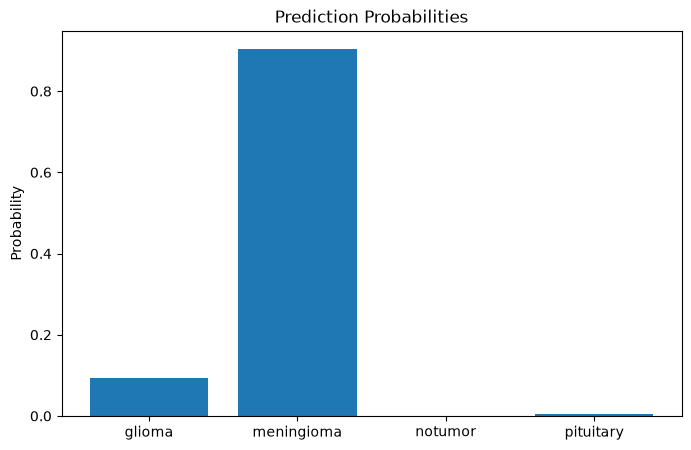

In [11]:
plt.figure(figsize=(8,5))

plt.bar(
    class_names,
    predictions[0]
)

plt.title(
    "Prediction Probabilities"
)

plt.ylabel("Probability")

plt.show()

In [12]:
def predict_mri(
    image_path,
    model
):

    img = tf.keras.utils.load_img(
        image_path,
        target_size=(224,224)
    )

    img_array = tf.keras.utils.img_to_array(
        img
    )

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    predictions = model.predict(
        img_array,
        verbose=0
    )

    class_id = np.argmax(
        predictions[0]
    )

    confidence = np.max(
        predictions[0]
    )

    return {
        "prediction":
            class_names[class_id],

        "confidence":
            float(confidence),

        "probabilities":
            predictions[0].tolist()
    }

In [13]:
result = predict_mri(
    image_path,
    model
)

result

{'prediction': 'meningioma',
 'confidence': 0.9032056331634521,
 'probabilities': [0.09254524111747742,
  0.9032056331634521,
  0.00044216279638931155,
  0.003807018743827939]}

In [14]:
print(
    f"Predicted Tumor: "
    f"{result['prediction']}"
)

print(
    f"Confidence: "
    f"{result['confidence']*100:.2f}%"
)

Predicted Tumor: meningioma
Confidence: 90.32%
